Please load `titanic.csv` and predict `Survived` using the same classification models we used in the demo (i.e. logistic regression, decision tree classification, and K-nearest neighbor classification). 
- Drop drop 'Name', 'Ticket'
- Create a new variable, 'num_families' by adding 'SibSp' and 'Parch'
- Once you create a num_families, drop 'SibSp' and 'Parch'

Answer the following questions and include your final code below. When you are done, click on Run > Restart Kernel and Run All Cells... and verify the output.
- Q: How did you encode categorical variables (list them) and why?
- A: Used One hot coding for Varibales named "Sex" And "Embarked" to create dummies and convert them to boolean data type
- Q: How many columns do you have in your X?
- A: 6 colummns
- Q: Which classification model performs the best (i.e. the best model with the highest f1 score & the best model with the highest recall score)?
- A: The best model is optimal regression with F1 score of 0.7424242424242424 and recall score of 0.7205882352941176

In [2]:
# import libraries: pandas and seaborn 
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('titanic.csv')

In [4]:
df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Survived
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,S,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0
...,...,...,...,...,...,...,...,...,...
884,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0
885,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1
886,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0
887,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Name      889 non-null    object 
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Ticket    889 non-null    object 
 7   Embarked  889 non-null    object 
 8   Survived  889 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 62.6+ KB


In [6]:
df=df.drop(columns='Name')
df=df.drop(columns='Ticket')
df

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,male,22.0,1,0,S,0
1,1,female,38.0,1,0,C,1
2,3,female,26.0,0,0,S,1
3,1,female,35.0,1,0,S,1
4,3,male,35.0,0,0,S,0
...,...,...,...,...,...,...,...
884,2,male,27.0,0,0,S,0
885,1,female,19.0,0,0,S,1
886,3,female,28.0,1,2,S,0
887,1,male,26.0,0,0,C,1


In [7]:
df['num_families']= df['SibSp']+df['Parch']
df

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived,num_families
0,3,male,22.0,1,0,S,0,1
1,1,female,38.0,1,0,C,1,1
2,3,female,26.0,0,0,S,1,0
3,1,female,35.0,1,0,S,1,1
4,3,male,35.0,0,0,S,0,0
...,...,...,...,...,...,...,...,...
884,2,male,27.0,0,0,S,0,0
885,1,female,19.0,0,0,S,1,0
886,3,female,28.0,1,2,S,0,3
887,1,male,26.0,0,0,C,1,0


In [8]:
df=df.drop(columns='SibSp')
df=df.drop(columns='Parch')
df

,Pclass,Sex,Age,Embarked,Survived,num_families
0,3,male,22.0,S,0,1
1,1,female,38.0,C,1,1
2,3,female,26.0,S,1,0
3,1,female,35.0,S,1,1
4,3,male,35.0,S,0,0
...,...,...,...,...,...,...
884,2,male,27.0,S,0,0
885,1,female,19.0,S,1,0
886,3,female,28.0,S,0,3
887,1,male,26.0,C,1,0


In [9]:
# one-hot encoding 
# pd.get_dummies(, drop_first=True) 
df=pd.get_dummies(data=df, drop_first=True)

In [10]:
df

,Pclass,Age,Survived,num_families,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,0,1,True,False,True
1,1,38.0,1,1,False,False,False
2,3,26.0,1,0,False,False,True
3,1,35.0,1,1,False,False,True
4,3,35.0,0,0,True,False,True
...,...,...,...,...,...,...,...
884,2,27.0,0,0,True,False,True
885,1,19.0,1,0,False,False,True
886,3,28.0,0,3,False,False,True
887,1,26.0,1,0,True,False,False


In [11]:
# check data info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        889 non-null    int64  
 1   Age           889 non-null    float64
 2   Survived      889 non-null    int64  
 3   num_families  889 non-null    int64  
 4   Sex_male      889 non-null    bool   
 5   Embarked_Q    889 non-null    bool   
 6   Embarked_S    889 non-null    bool   
dtypes: bool(3), float64(1), int64(3)
memory usage: 30.5 KB


In [12]:
corr_mat=df[['Pclass','Age','Survived','num_families']].corr()

<Axes: >

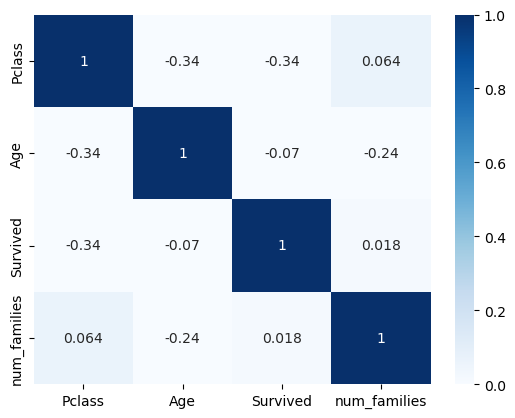

In [13]:
sns.heatmap(corr_mat, annot=True, cmap='Blues', vmin=0, vmax=1)

In [14]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

In [15]:
y=df['Survived']

In [16]:
X=df.drop(columns='Survived')

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
st_scaler=StandardScaler()
st_scaler

StandardScaler()

In [19]:
for_st_scaler=X.select_dtypes('number')

In [20]:
for_st_scaler

,Pclass,Age,num_families
0,3,22.0,1
1,1,38.0,1
2,3,26.0,0
3,1,35.0,1
4,3,35.0,0
...,...,...,...
884,2,27.0,0
885,1,19.0,0
886,3,28.0,3
887,1,26.0,0


In [21]:
scaled=st_scaler.fit_transform(for_st_scaler)
scaled

array([[ 0.82520863, -0.56367407,  0.05785331],
       [-1.57221121,  0.66921696,  0.05785331],
       [ 0.82520863, -0.25545131, -0.5618044 ],
       ...,
       [ 0.82520863, -0.10133993,  1.29716872],
       [-1.57221121, -0.25545131, -0.5618044 ],
       [ 0.82520863,  0.20688282, -0.5618044 ]])

In [22]:
# assign the scaled values to X data frame
X[['Pclass','Age','num_families']]=scaled

In [23]:
X

,Pclass,Age,num_families,Sex_male,Embarked_Q,Embarked_S
0,0.825209,-0.563674,0.057853,True,False,True
1,-1.572211,0.669217,0.057853,False,False,False
2,0.825209,-0.255451,-0.561804,False,False,True
3,-1.572211,0.438050,0.057853,False,False,True
4,0.825209,0.438050,-0.561804,True,False,True
...,...,...,...,...,...,...
884,-0.373501,-0.178396,-0.561804,True,False,True
885,-1.572211,-0.794841,-0.561804,False,False,True
886,0.825209,-0.101340,1.297169,False,False,True
887,-1.572211,-0.255451,-0.561804,True,False,False


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
logr=LogisticRegression()

In [28]:
logr.fit(X_train, y_train)

LogisticRegression()

In [29]:
pred_logr=logr.predict(X_test)
pred_logr

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [30]:
y_test

159    0
125    0
427    0
421    0
564    0
      ..
39     1
90     0
881    0
851    1
636    0
Name: Survived, Length: 178, dtype: int64

In [31]:
comparison=pd.DataFrame({'Actual':y_test, 'Predicted':pred_logr})
comparison

,Actual,Predicted
159,0,0
125,0,0
427,0,0
421,0,0
564,0,0
...,...,...
39,1,1
90,0,0
881,0,0
851,1,1


In [32]:
logr.intercept_

array([1.26441979])

In [33]:
coefficient=logr.coef_.T

In [34]:
coefficient=pd.DataFrame(coefficient, columns=['coefficient'], index=X.columns)

In [35]:
coefficient['abs_coefficient']=coefficient['coefficient'].abs()

In [36]:
coefficient.sort_values('abs_coefficient', ascending=False)

,coefficient,abs_coefficient
Sex_male,-2.572008,2.572008
Pclass,-0.912128,0.912128
Age,-0.451430,0.451430
Embarked_S,-0.360862,0.360862
Embarked_Q,0.285366,0.285366
num_families,-0.238262,0.238262


In [37]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



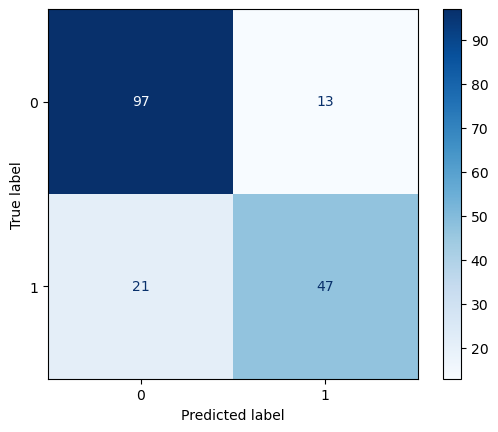

In [38]:
print(classification_report(y_test, pred_logr))
# display ConfusionMatrixDisplay 
ConfusionMatrixDisplay.from_predictions(y_test, pred_logr, cmap='Blues')

In [44]:
from sklearn.metrics import precision_recall_curve

In [47]:
pred_prob=logr.predict_proba(X_test)
pred_prob

array([[0.95006204, 0.04993796],
       [0.83136243, 0.16863757],
       [0.83136243, 0.16863757],
       [0.90689737, 0.09310263],
       [0.91665037, 0.08334963],
       [0.04839678, 0.95160322],
       [0.89446527, 0.10553473],
       [0.14723478, 0.85276522],
       [0.10272171, 0.89727829],
       [0.91534234, 0.08465766],
       [0.83136243, 0.16863757],
       [0.21965069, 0.78034931],
       [0.13871234, 0.86128766],
       [0.25213814, 0.74786186],
       [0.07054867, 0.92945133],
       [0.33373778, 0.66626222],
       [0.30311784, 0.69688216],
       [0.22790297, 0.77209703],
       [0.8730805 , 0.1269195 ],
       [0.87900162, 0.12099838],
       [0.56465998, 0.43534002],
       [0.91799922, 0.08200078],
       [0.86516918, 0.13483082],
       [0.92308627, 0.07691373],
       [0.434678  , 0.565322  ],
       [0.48436052, 0.51563948],
       [0.61772965, 0.38227035],
       [0.27795341, 0.72204659],
       [0.89770413, 0.10229587],
       [0.10678044, 0.89321956],
       [0.

In [50]:
precision, recall, thresholds=precision_recall_curve(y_test,pred_prob[:,1])

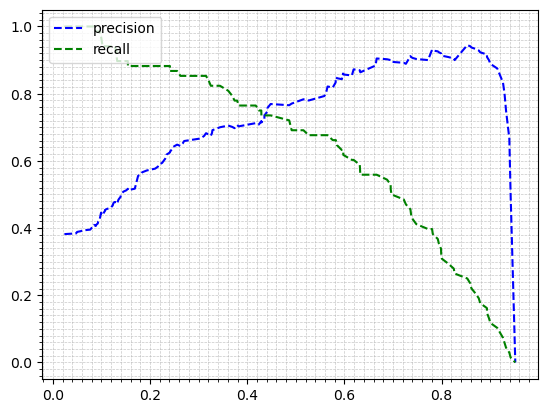

In [53]:
import matplotlib.pyplot as plt 
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.plot(thresholds, precision[:-1], 'b--', label = 'precision')
plt.plot(thresholds, recall[:-1], 'g--', label = 'recall')
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.02))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.02))
plt.legend(loc = 'upper left')

In [56]:
pred_logr2=pred_prob[:,1]>=0.47
pred_logr2

array([False, False, False, False, False,  True, False,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False,  True,  True, False,
        True, False,  True,  True, False, False, False, False, False,
       False, False, False, False,  True, False,  True,  True, False,
       False,  True, False,  True, False, False, False, False,  True,
        True, False, False,  True, False,  True, False,  True, False,
       False,  True, False, False, False, False,  True,  True, False,
        True, False,  True, False, False, False, False, False, False,
        True, False, False, False,  True,  True, False,  True, False,
       False, False,  True, False, False, False,  True, False,  True,
        True, False, False,  True, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False,  True, False,
       False, False,

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.74        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



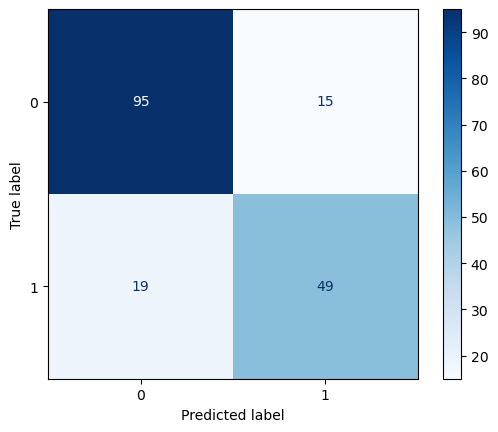

In [66]:
print(classification_report(y_test, pred_logr2))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logr2, cmap='Blues')

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
DTC=DecisionTreeClassifier()

In [75]:
DTC.fit(X_train, y_train)

DecisionTreeClassifier()

In [78]:
preddtc=DTC.predict(X_test)
preddtc

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        68

    accuracy                           0.79       178
   macro avg       0.77      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



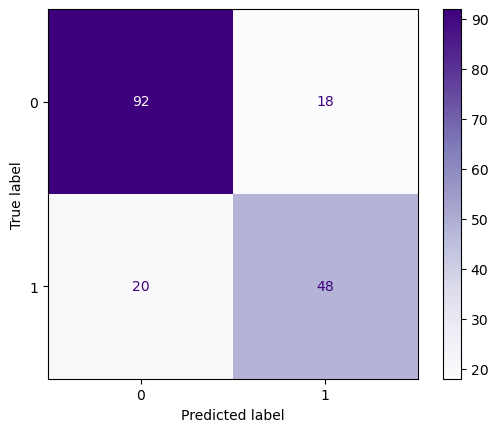

In [81]:
print(classification_report(y_test, preddtc))
ConfusionMatrixDisplay.from_predictions(y_test, preddtc, cmap='Purples')

In [85]:
from sklearn.neighbors import KNeighborsClassifier

In [88]:
knr=KNeighborsClassifier()

In [91]:
knr.fit(X_train, y_train)

KNeighborsClassifier()

In [94]:
predknr=knr.predict(X_test)
predknr

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0])

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.76      0.66      0.71        68

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



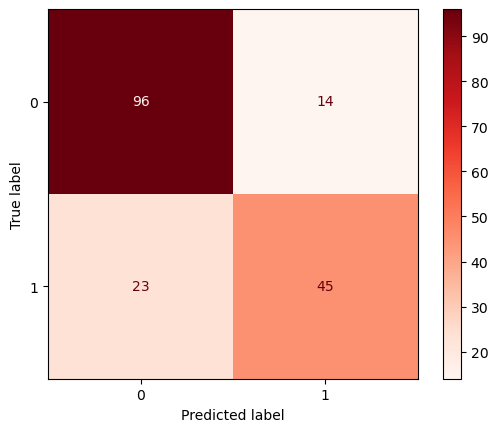

In [97]:
print(classification_report(y_test, predknr))

ConfusionMatrixDisplay.from_predictions(y_test, predknr, cmap='Reds')

In [110]:
f1loogr=f1_score(y_test,pred_logr)
f1loogr2=f1_score(y_test,pred_logr2)
f1dtc=f1_score(y_test,preddtc)
f1knr=f1_score(y_test,predknr)
Recallloogr=recall_score(y_test,pred_logr)
Recallloogr2=recall_score(y_test,pred_logr2)
Recalldtc=recall_score(y_test,preddtc)
Recallknr=recall_score(y_test,predknr)

In [116]:
best_model=max((f1loogr,Recallloogr, 'logical regression'),(f1loogr2,Recallloogr2, 'optimal regression'),(f1dtc,Recalldtc,'Decision Tree Classification'),(f1knr,Recallknr,'K-Nearest neighbor classification'))

In [120]:

print(f"The best model is {best_model[2]} with F1 score of {best_model[0]} and recall score of {best_model[1]}")


The best model is optimal regression with F1 score of 0.7424242424242424 and recall score of 0.7205882352941176
